In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline



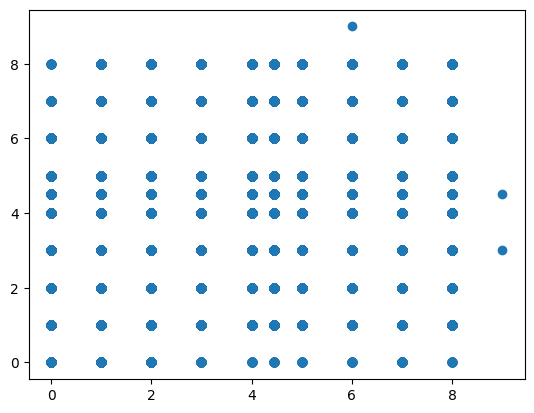

In [7]:
path=r'C:\Users\samik\Downloads\weatherAUS (3).zip'
data= pd.read_csv(path)
data = data.drop(columns=['Date','Location','Evaporation','Sunshine','WindGustDir','WindDir9am','WindDir3pm','RainToday','RainTomorrow'])
column_mean= data['Rainfall'].replace(0, pd.NA).mean()
data['Rainfall']=data['Rainfall'].replace(0,column_mean)
data = data.fillna(data.mean())
data.head()
plt.scatter(data['Cloud9am'],data['Cloud3pm'])


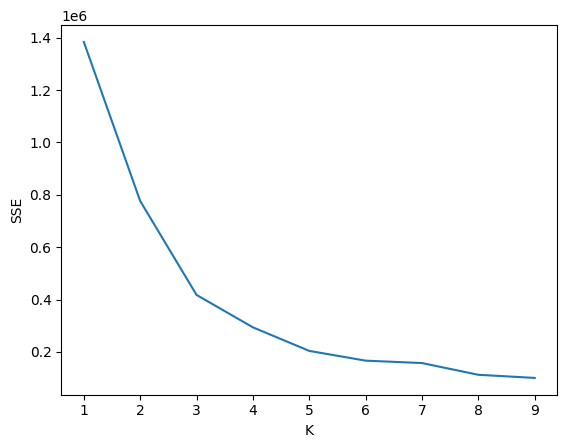

In [8]:
k_rng=range(1,10)
sse=[]
for k in k_rng:
    km=KMeans(n_clusters=k)
    km.fit(data[['Cloud9am','Cloud3pm']])
    sse.append(km.inertia_)
sse
plt.xlabel('K')
plt.ylabel('SSE')
plt.plot(k_rng,sse)
    

In [9]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(data[['Cloud9am','Cloud3pm']])
data['cluter']=y_predicted
data.head()


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,cluter
0,13.4,22.9,0.600000,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8,1
1,7.4,25.1,6.567425,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3,0
2,12.9,25.7,6.567425,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2,0
3,9.2,28.0,6.567425,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5,0
4,17.5,32.3,1.000000,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7,1


C:\Users\samik\AppData\Local\Temp\ipykernel_18924\2879569212.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


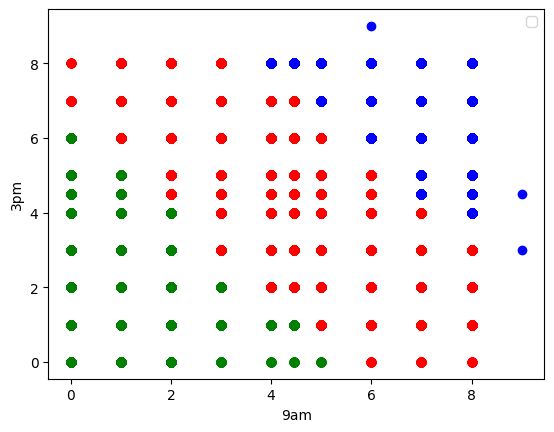

In [10]:
data1=data[data.cluter==0]
data2=data[data.cluter==1]
data3=data[data.cluter==2]

plt.scatter(data1['Cloud9am'],data1['Cloud3pm'],color='red')
plt.scatter(data2['Cloud9am'],data2['Cloud3pm'],color='blue')
plt.scatter(data3['Cloud9am'],data3['Cloud3pm'],color='green')

plt.xlabel('9am')
plt.ylabel('3pm')
plt.legend()